#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Titanic

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=blue> 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde
import numpy as np

## <font color=blue> 2. Carregamento e Preparação do Dataset

In [2]:
# constantes pra usar nos graficos
CORES_CLASSE = {1: "gold", 2: "steelblue", 3: "tomato"}
LABELS_CLASSE = {1: "1ª Classe", 2: "2ª Classe", 3: "3ª Classe"}
CORES_RESULTADO = {"Sobreviveu": "seagreen", "Não Sobreviveu": "tomato"}

### 2.1 Carregamento do dataset

**observações:**
- 887 passageiros. sem valores ausentes
- variáveis numéricas e categóricas disponíveis para análise de sobrevivência

In [3]:
PATH_TITANIC = "/home/heitor/Documentos/MBA/01_estatistica/01_estatistica-titanic/titanic.csv"

titanic_df = pd.read_csv(PATH_TITANIC)
titanic_df.columns = titanic_df.columns.str.strip()

print(f"titanic_df: {titanic_df.shape}")
titanic_df.info()

titanic_df: (887, 8)
<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    str    
 3   Sex                      887 non-null    str    
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 55.6 KB


### 2.2 Feature Engineering

- **AgeGroup**: fiz faixas etárias para melhorar a análise (criança: 0-12, jovem: 13-17, adulto: 18-59, idoso: 60+)

In [4]:
bins = [0, 12, 17, 59, 100]
labels = ["Criança", "Jovem", "Adulto", "Idoso"]
titanic_df["AgeGroup"] = pd.cut(titanic_df["Age"], bins=bins, labels=labels, right=True)

print("Distribuição por AgeGroup:")
print(titanic_df["AgeGroup"].value_counts().sort_index())

Distribuição por AgeGroup:
AgeGroup
Criança     79
Jovem       51
Adulto     726
Idoso       31
Name: count, dtype: int64


### 2.3 Visão geral do dataset

In [5]:
titanic_df.info()
titanic_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Survived                 887 non-null    int64   
 1   Pclass                   887 non-null    int64   
 2   Name                     887 non-null    str     
 3   Sex                      887 non-null    str     
 4   Age                      887 non-null    float64 
 5   Siblings/Spouses Aboard  887 non-null    int64   
 6   Parents/Children Aboard  887 non-null    int64   
 7   Fare                     887 non-null    float64 
 8   AgeGroup                 887 non-null    category
dtypes: category(1), float64(2), int64(4), str(2)
memory usage: 56.6 KB


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,AgeGroup
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,Adulto
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,Adulto
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,Adulto
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,Adulto
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,Adulto
5,0,3,Mr. James Moran,male,27.0,0,0,8.4583,Adulto
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,Adulto
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,Criança
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,Adulto
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,Jovem


## <font color=blue> 3. Análise Exploratória dos Dados

### 3.1 Distribuição da Tarifa

**observações:**
- passageiros com `Fare = 0` excluídos do histograma. representam casos especiais (tripulação ou embarque gratuito), não tarifas reais
- a inclusão desses valores puxaria média e mediana para baixo

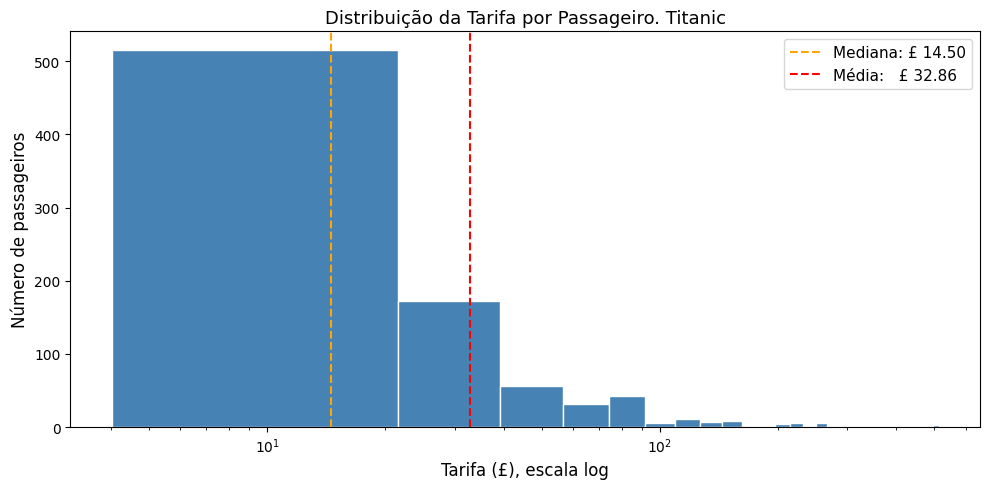

In [6]:
mask_com_tarifa = titanic_df["Fare"] > 0
tarifas = titanic_df[mask_com_tarifa]["Fare"]

n_bins = np.sqrt(len(titanic_df)).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tarifas, bins=n_bins, edgecolor="white", color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Tarifa (£), escala log", fontsize=12)
ax.set_ylabel("Número de passageiros", fontsize=12)
ax.set_title("Distribuição da Tarifa por Passageiro. Titanic", fontsize=13)
ax.axvline(
    tarifas.median(),
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Mediana: £ {tarifas.median():,.2f}",
)
ax.axvline(
    tarifas.mean(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Média:   £ {tarifas.mean():,.2f}",
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**observações:**
- distribuição assimétrica à direita
- mediana: £ 14.50. média: £ 32.86. razão de ~2.3x
- concentração de tarifas elevadas em poucos passageiros

#### 3.1.2 Distribuição da Tarifa por Classe. Densidade

O histograma geral mostra a distribuição agregada, mas mistura três populações distintas. Ploto um gráfico de densidade separado por classe em escala logarítmica para revelar o comportamento individual de cada grupo e identificar possíveis multimodalidades.

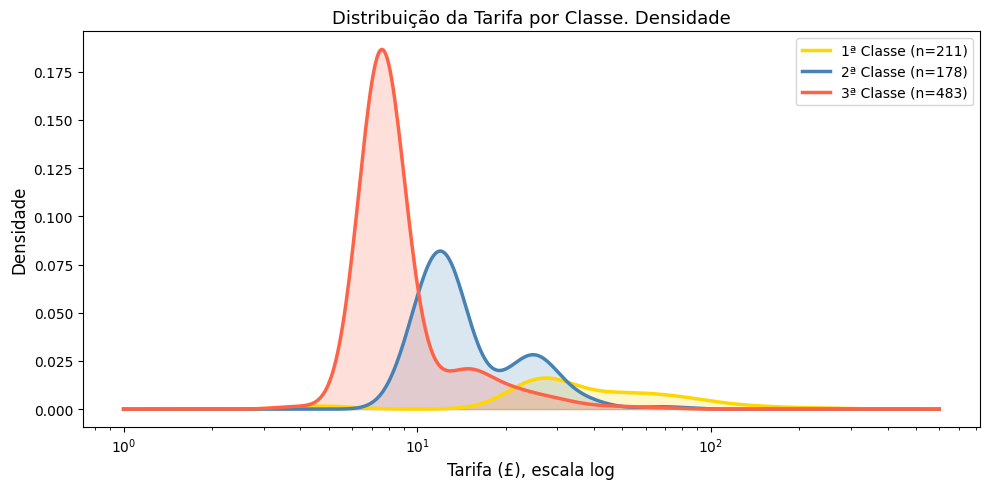

In [7]:
# densidade em escala log, separa os três grupos com clareza
# sem distorção de volume, as diferenças multiplicativas viram lineares
x_range = np.logspace(np.log10(1), np.log10(600), 500)

fig, ax = plt.subplots(figsize=(10, 5))
for classe, cor in CORES_CLASSE.items():
    dados_classe = titanic_df[
        (titanic_df["Pclass"] == classe) & (titanic_df["Fare"] > 0)
    ]["Fare"]
    kde = gaussian_kde(np.log(dados_classe))
    densidade = kde(np.log(x_range)) / x_range
    ax.plot(
        x_range,
        densidade,
        color=cor,
        linewidth=2.5,
        label=f"{LABELS_CLASSE[classe]} (n={len(dados_classe)})",
    )
    ax.fill_between(x_range, densidade, alpha=0.2, color=cor)

ax.set_xscale("log")
ax.set_xlabel("Tarifa (£), escala log", fontsize=12)
ax.set_ylabel("Densidade", fontsize=12)
ax.set_title("Distribuição da Tarifa por Classe. Densidade", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**observações:**
- 3a classe: pico próximo a £ 8. passageiros concentrados entre £ 5 e £ 30
- 2a classe: dois picos em torno de £ 13 e £ 26. dois subgrupos com precificações distintas
- 1a classe: distribuição longa com tarifas que chegam a £ 500. alta variabilidade interna

### 3.2 Distribuição por Classe

#### 3.2.1 Total de passageiros por classe

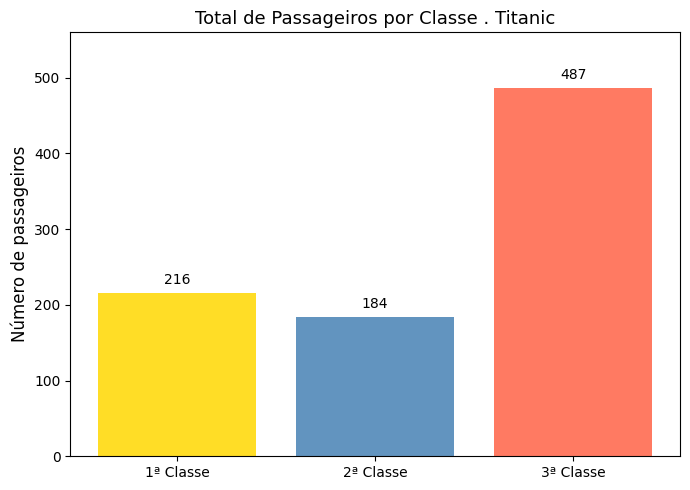

In [8]:
passageiros_classe = titanic_df["Pclass"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [LABELS_CLASSE[p] for p in passageiros_classe.index],
    passageiros_classe.values,
    color=[CORES_CLASSE[p] for p in passageiros_classe.index],
    alpha=0.85,
)
ax.set_ylabel("Número de passageiros", fontsize=12)
ax.set_title("Total de Passageiros por Classe . Titanic", fontsize=13)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=10)
ax.set_ylim(0, passageiros_classe.max() * 1.15)
plt.tight_layout()
plt.show()

**observações:**
- 3a classe: 487 passageiros (54.9%)
- 1a classe: 216 passageiros (24.4%)
- 2a classe: 184 passageiros (20.7%)

#### 3.2.2 Taxa de sobrevivência por classe

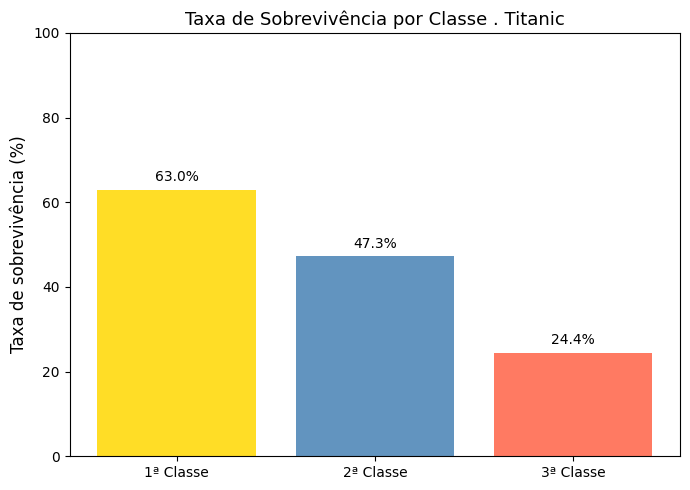

In [9]:
sobrevivencia_classe = (
    titanic_df.groupby("Pclass")["Survived"].mean().sort_index() * 100
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [LABELS_CLASSE[p] for p in sobrevivencia_classe.index],
    sobrevivencia_classe.values,
    color=[CORES_CLASSE[p] for p in sobrevivencia_classe.index],
    alpha=0.85,
)
ax.set_ylabel("Taxa de sobrevivência (%)", fontsize=12)
ax.set_title("Taxa de Sobrevivência por Classe . Titanic", fontsize=13)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

**observações:**
- 1a classe: 62.9% de taxa de sobrevivência
- 2a classe: 43.5% de taxa de sobrevivência
- 3a classe: 24.2% de taxa de sobrevivência
- diferença entre 1a e 3a classe: 38.7 pontos percentuais

### 3.3 Sobrevivência por Variáveis Qualitativas

Para cada variável qualitativa (Sexo, Classe e Faixa Etária), apresento três tipos de visualização:

1. **Representatividade**: gráfico de barras comparando a proporção de passageiros de cada categoria com a proporção de sobreviventes que essa categoria representa. Permite identificar se algum grupo sobreviveu proporcionalmente mais do que sua presença numérica.

2. **Distribuição da tarifa**: box plot em escala logarítmica mostrando a dispersão das tarifas dentro de cada categoria. Excluo passageiros com `Fare = 0` para focar na distribuição real.

3. **Resultado por categoria**: dois gráficos lado a lado. (a) barras empilhadas com a taxa de sobrevivência e não sobrevivência por categoria. e (b) barras agrupadas com a tarifa média de sobreviventes e não sobreviventes por categoria.

#### 3.3.0 Funções genéricas de plot

In [10]:
def plot_representatividade(df, coluna, titulo, ax, order=None, label_map=None):
    total_pass = df[coluna].value_counts(normalize=True) * 100
    total_surv = df[df["Survived"] == 1][coluna].value_counts(normalize=True) * 100
    categorias = order if order is not None else total_pass.index.tolist()
    labels = [
        label_map[c] if label_map and c in label_map else str(c) for c in categorias
    ]
    x = range(len(categorias))
    w = 0.35
    bars1 = ax.bar(
        [i - w / 2 for i in x],
        [total_pass.get(c, 0) for c in categorias],
        width=w,
        label="% de passageiros",
        color=CORES_RESULTADO["Não Sobreviveu"],
        alpha=0.8,
    )
    bars2 = ax.bar(
        [i + w / 2 for i in x],
        [total_surv.get(c, 0) for c in categorias],
        width=w,
        label="% dos sobreviventes",
        color=CORES_RESULTADO["Sobreviveu"],
        alpha=0.8,
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=0, ha="center")
    ax.set_ylabel("Percentual (%)")
    ax.set_title(titulo)
    ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=8)
    ax.legend()


def plot_boxplot_tarifa(
    df,
    coluna,
    categorias,
    titulo,
    cor="steelblue",
    cores=None,
    figsize=(10, 5),
    labels=None,
):
    mask_com_tarifa = df["Fare"] > 0
    box_df = df[mask_com_tarifa]
    dados = [box_df[box_df[coluna] == c]["Fare"].dropna() for c in categorias]
    labels = labels or [str(x) for x in categorias]
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(
        dados,
        tick_labels=labels,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(cores[i] if cores else cor)
        patch.set_alpha(0.6)
    ax.set_yscale("log")
    ax.set_ylabel("Tarifa (£), escala log", fontsize=12)
    ax.set_title(f"Distribuição da Tarifa por {titulo}. Titanic", fontsize=13)
    plt.xticks(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()
    for label, d in zip(labels, dados):
        print(f"{label}: mediana = £ {d.median():,.2f} | n = {len(d)}")


def plot_sobrevivencia_por_variavel(
    df, coluna, categorias, titulo, figsize=(13, 5), label_map=None
):
    df = df.copy()
    df["Resultado"] = df["Survived"].map({1: "Sobreviveu", 0: "Não Sobreviveu"})
    labels = [
        label_map[c] if label_map and c in label_map else str(c) for c in categorias
    ]

    proporcoes = (
        df.groupby([coluna, "Resultado"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Sobreviveu", "Não Sobreviveu"], fill_value=0)
    )
    proporcoes = proporcoes.div(proporcoes.sum(axis=1), axis=0) * 100
    proporcoes = proporcoes.reindex(categorias)

    tarifa_media = (
        df.groupby([coluna, "Resultado"])["Fare"]
        .mean()
        .unstack(fill_value=0)
        .reindex(columns=["Sobreviveu", "Não Sobreviveu"], fill_value=0)
        .reindex(categorias)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    bottom = [0] * len(categorias)
    for resultado in ["Sobreviveu", "Não Sobreviveu"]:
        vals = proporcoes[resultado].tolist()
        ax1.bar(
            range(len(categorias)),
            vals,
            bottom=bottom,
            label=resultado,
            color=CORES_RESULTADO[resultado],
            alpha=0.8,
        )
        bottom = [b + v for b, v in zip(bottom, vals)]
    ax1.set_xticks(range(len(categorias)))
    ax1.set_xticklabels(labels, rotation=0, ha="center", fontsize=9)
    ax1.set_ylabel("% de passageiros")
    ax1.set_title(f"Taxa de sobrevivência por {titulo}")
    ax1.legend(loc="upper right", fontsize=8)

    x = range(len(categorias))
    w = 0.35
    for i, resultado in enumerate(["Sobreviveu", "Não Sobreviveu"]):
        vals = tarifa_media[resultado].tolist()
        ax2.bar(
            [xi + (i - 0.5) * w for xi in x],
            vals,
            width=w,
            label=resultado,
            color=CORES_RESULTADO[resultado],
            alpha=0.8,
        )
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(labels, rotation=0, ha="center", fontsize=9)
    ax2.set_ylabel("Tarifa média (£)")
    ax2.set_title(f"Tarifa média por resultado. {titulo}")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

#### 3.3.1 Sexo

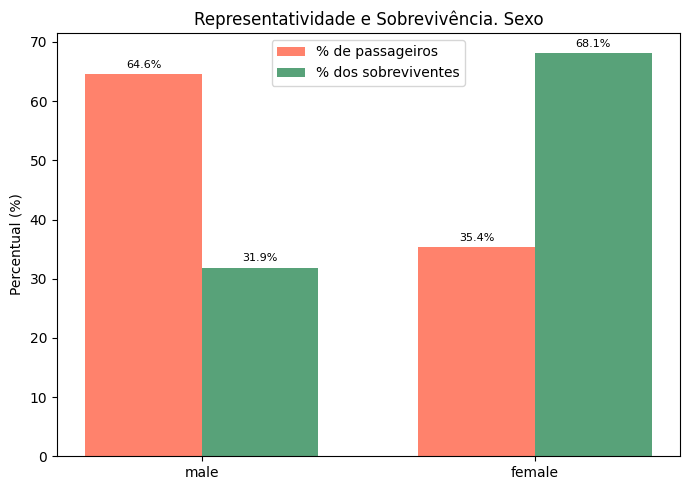

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_representatividade(
    titanic_df, "Sex", "Representatividade e Sobrevivência. Sexo", ax
)
plt.tight_layout()
plt.show()

##### Distribuição da Tarifa por Sexo

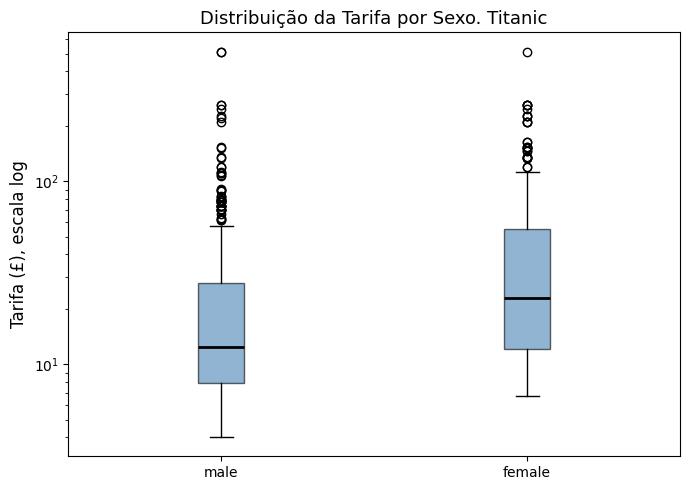

male: mediana = £ 12.41 | n = 558
female: mediana = £ 23.00 | n = 314


In [12]:
plot_boxplot_tarifa(
    titanic_df, "Sex", categorias=["male", "female"], titulo="Sexo", figsize=(7, 5)
)

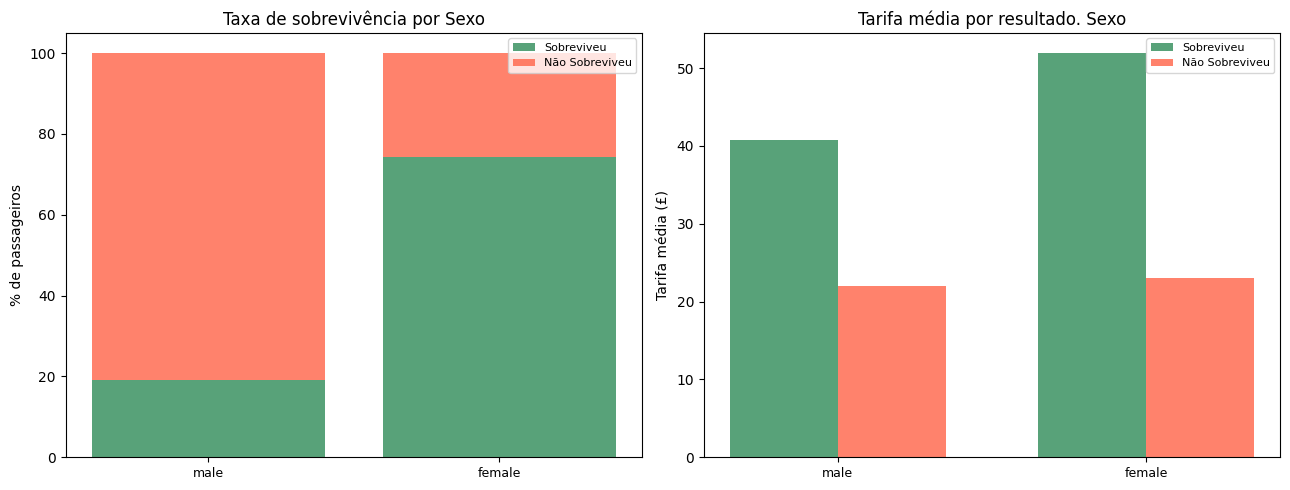

In [13]:
plot_sobrevivencia_por_variavel(
    titanic_df, "Sex", categorias=["male", "female"], titulo="Sexo"
)

**observações:**
- mulheres: 74.2% de taxa de sobrevivência (314 passageiras)
- homens: 18.9% de taxa de sobrevivência (573 passageiros)
- diferença de 55.3 pontos percentuais

#### 3.3.2 Classe

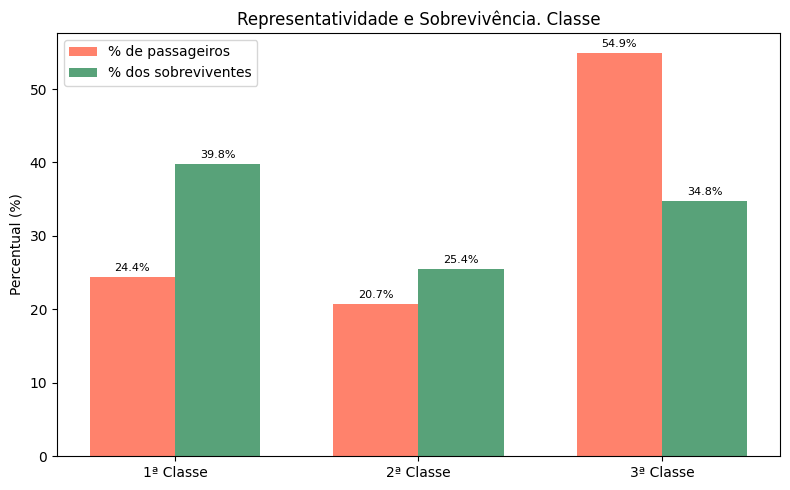

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_representatividade(
    titanic_df,
    "Pclass",
    "Representatividade e Sobrevivência. Classe",
    ax,
    order=[1, 2, 3],
    label_map=LABELS_CLASSE,
)
plt.tight_layout()
plt.show()

##### Distribuição da Tarifa por Classe

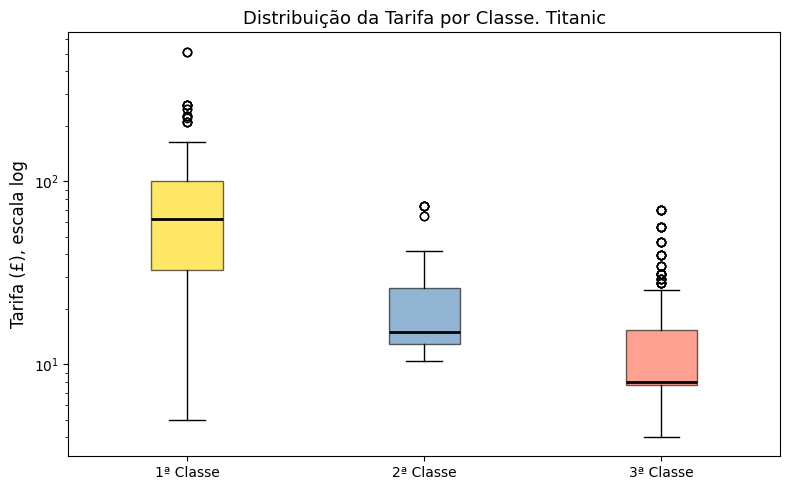

1ª Classe: mediana = £ 61.98 | n = 211
2ª Classe: mediana = £ 15.02 | n = 178
3ª Classe: mediana = £ 8.05 | n = 483


In [15]:
plot_boxplot_tarifa(
    titanic_df,
    "Pclass",
    categorias=[1, 2, 3],
    labels=[LABELS_CLASSE[c] for c in [1, 2, 3]],
    cores=[CORES_CLASSE[c] for c in [1, 2, 3]],
    titulo="Classe",
    figsize=(8, 5),
)

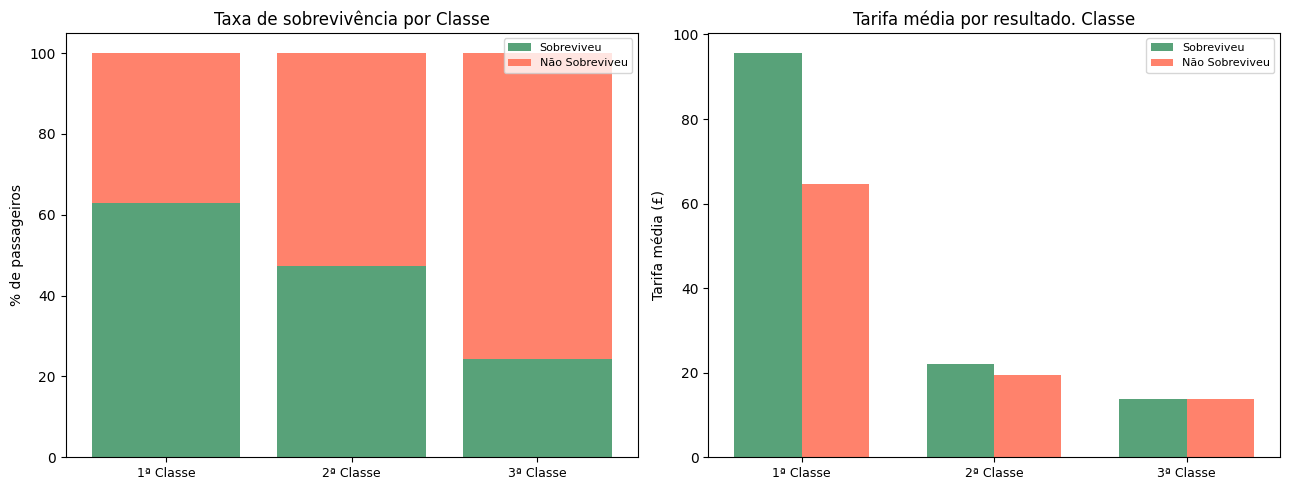

In [16]:
plot_sobrevivencia_por_variavel(
    titanic_df, "Pclass", categorias=[1, 2, 3], titulo="Classe", label_map=LABELS_CLASSE
)

**observações:**
- 1a classe: tarifa mediana maior e taxa de sobrevivência de 62.9%
- 3a classe: tarifa mediana menor e taxa de sobrevivência de 24.2%
- dentro da 1a classe, sobreviventes pagaram tarifas médias acima dos não sobreviventes

#### 3.3.3 Faixa Etária

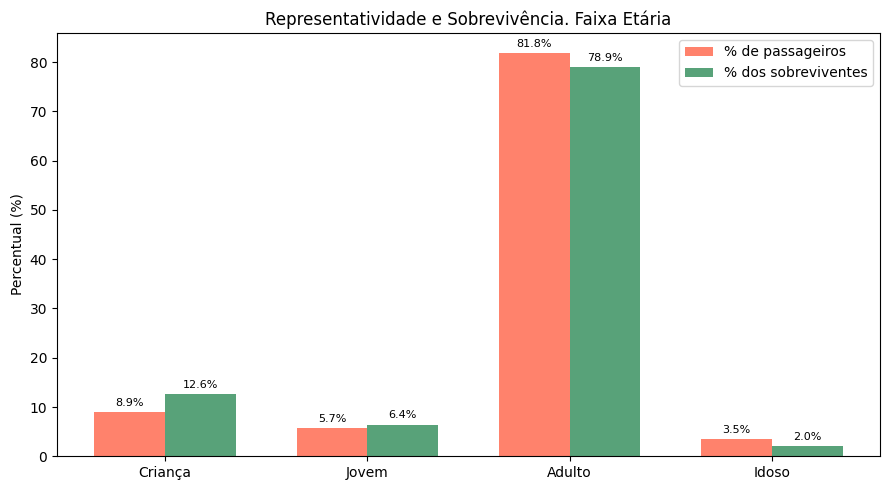

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_representatividade(
    titanic_df,
    "AgeGroup",
    "Representatividade e Sobrevivência. Faixa Etária",
    ax,
    order=["Criança", "Jovem", "Adulto", "Idoso"],
)
plt.tight_layout()
plt.show()

##### Distribuição da Tarifa por Faixa Etária

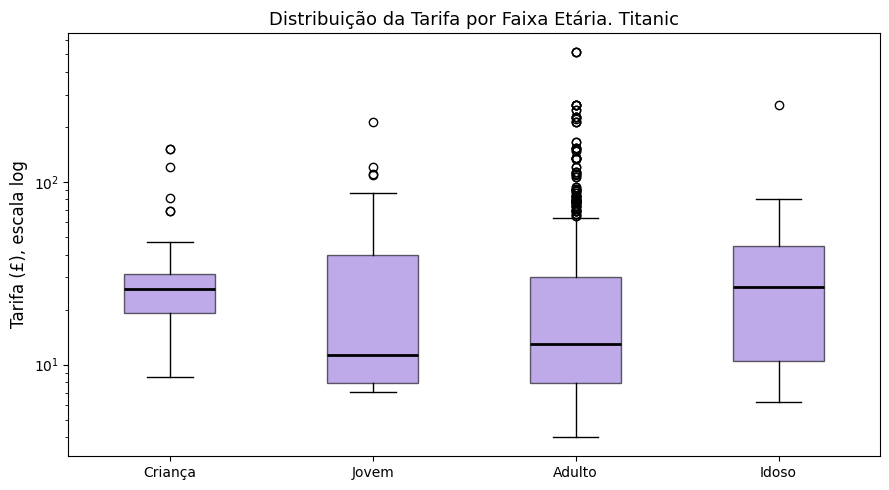

Criança: mediana = £ 26.00 | n = 79
Jovem: mediana = £ 11.24 | n = 51
Adulto: mediana = £ 13.00 | n = 711
Idoso: mediana = £ 26.55 | n = 31


In [18]:
plot_boxplot_tarifa(
    titanic_df,
    "AgeGroup",
    categorias=["Criança", "Jovem", "Adulto", "Idoso"],
    titulo="Faixa Etária",
    cor="mediumpurple",
    figsize=(9, 5),
)

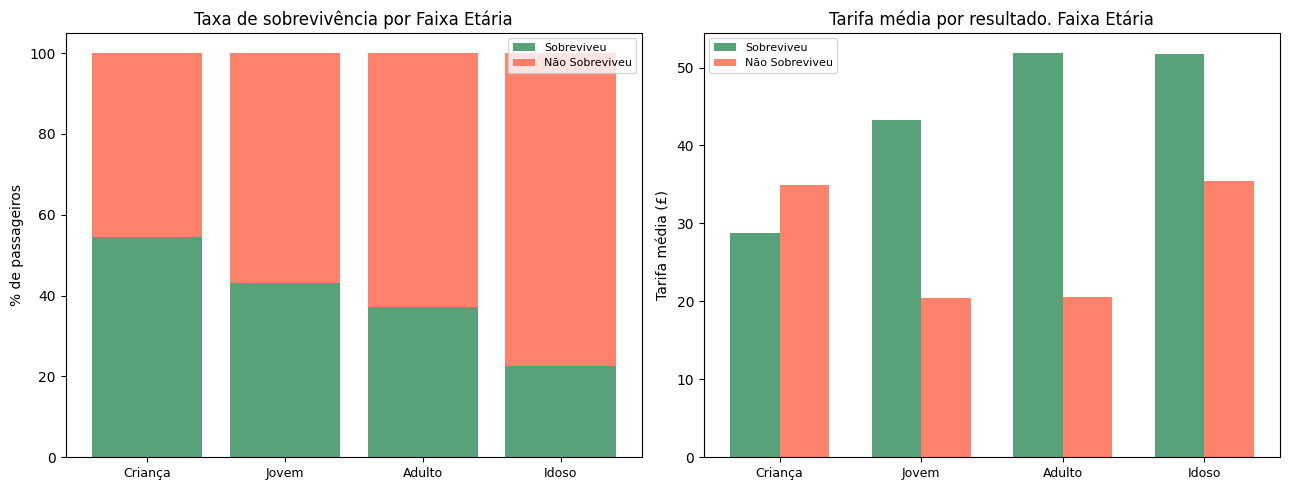

In [19]:
plot_sobrevivencia_por_variavel(
    titanic_df,
    "AgeGroup",
    categorias=["Criança", "Jovem", "Adulto", "Idoso"],
    titulo="Faixa Etária",
)

**observações:**
- crianças: maior taxa de sobrevivência entre as faixas etárias
- adultos: 80% dos passageiros. maior volume absoluto de vítimas
- idosos: menor taxa de sobrevivência entre todas as faixas
- jovens (13-17): grupo pequeno. resultados com menor representatividade

## <font color=blue> 4. Síntese e Conclusões

Nesta seção, reúno as principais medidas descritivas da análise em tabelas resumo para as inferências sobre o perfil dos passageiros e os fatores associados à sobrevivência.

### 4.1 Perfil Geral dos Passageiros

Medidas de posição e dispersão da tarifa e da idade para o universo completo de passageiros.

In [20]:
resumo = (
    pd.DataFrame(
        {
            "Tarifa (£)": titanic_df["Fare"],
            "Idade": titanic_df["Age"],
        }
    )
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
)

resumo.columns = ["N", "Média", "Mediana", "Desvio Padrão", "Mínimo", "Máximo"]
resumo.insert(
    6,
    "Assimetria",
    [
        skew(titanic_df["Fare"]),
        skew(titanic_df["Age"]),
    ],
)
resumo["Razão Média/Mediana"] = resumo["Média"] / resumo["Mediana"]

display(
    resumo.style.format(
        {
            "N": "{:,.0f}",
            "Média": "{:,.2f}",
            "Mediana": "{:,.2f}",
            "Desvio Padrão": "{:,.2f}",
            "Mínimo": "{:,.2f}",
            "Máximo": "{:,.2f}",
            "Assimetria": "{:.2f}",
            "Razão Média/Mediana": "{:.1f}x",
        }
    ).set_caption("Tabela 4.1, Medidas descritivas de Tarifa e Idade")
)

,N,Média,Mediana,Desvio Padrão,Mínimo,Máximo,Assimetria,Razão Média/Mediana
Tarifa (£),887,32.31,14.45,49.78,0.00,512.33,4.77,2.2x
Idade,887,29.47,28.00,14.12,0.42,80.00,0.45,1.1x


**observações:**
- tarifa: assimetria de 4.79. média (£ 32.30) é 2.2x a mediana (£ 14.45)
- idade: mediana de 28 anos e média de 29.5 anos. distribuição mais simétrica

### 4.2 Sobrevivência por Grupo

In [21]:
res_df = titanic_df.copy()
res_df["Resultado"] = res_df["Survived"].map({1: "Sobreviveu", 0: "Não Sobreviveu"})

tabela_resultado = (
    res_df.groupby("Resultado")
    .agg(
        N=("Fare", "count"),
        Tarifa_Media=("Fare", "mean"),
        Tarifa_Mediana=("Fare", "median"),
        Idade_Media=("Age", "mean"),
        Idade_Mediana=("Age", "median"),
    )
    .reindex(["Sobreviveu", "Não Sobreviveu"])
)

tabela_resultado["Taxa (%)"] = (
    tabela_resultado["N"] / tabela_resultado["N"].sum() * 100
).map("{:.1f}%".format)

tabela_resultado.columns = [
    "N",
    "Tarifa Média",
    "Tarifa Mediana",
    "Idade Média",
    "Idade Mediana",
    "Taxa (%)",
]

display(
    tabela_resultado.style.format(
        {
            "N": "{:,.0f}",
            "Tarifa Média": "£ {:,.2f}",
            "Tarifa Mediana": "£ {:,.2f}",
            "Idade Média": "{:.1f}",
            "Idade Mediana": "{:.1f}",
        }
    ).set_caption("Tabela 4.2, Perfil de Sobreviventes e Não Sobreviventes")
)

,N,Tarifa Média,Tarifa Mediana,Idade Média,Idade Mediana,Taxa (%)
Resultado,,,,,,
Sobreviveu,342,£ 48.40,£ 26.00,28.4,28.0,38.6%
Não Sobreviveu,545,£ 22.21,£ 10.50,30.1,28.0,61.4%


**observações:**
- sobreviventes pagaram tarifa média de £ 48.40 vs £ 22.12 dos não sobreviventes. razão de ~2.2x
- tarifa mediana dos sobreviventes também acima. relação consistente com a classe econômica
- idade média dos sobreviventes abaixo da dos não sobreviventes. reflexo da prioridade a crianças

### 4.3 Desigualdades Demográficas na Sobrevivência

In [22]:
def tabela_demografica_titanic(df, coluna, categorias):
    rows = []
    for cat in categorias:
        sub = df[df[coluna] == cat]
        rows.append(
            {
                "Categoria": str(cat),
                "N Passageiros": len(sub),
                "% Passageiros": len(sub) / len(df) * 100,
                "Taxa Sobrevivência (%)": sub["Survived"].mean() * 100,
                "Tarifa Média": sub["Fare"].mean(),
                "Tarifa Mediana": sub["Fare"].median(),
                "Idade Média": sub["Age"].mean(),
            }
        )
    return pd.DataFrame(rows).set_index("Categoria")


fmt = {
    "N Passageiros": "{:,.0f}",
    "% Passageiros": "{:.1f}%",
    "Taxa Sobrevivência (%)": "{:.1f}%",
    "Tarifa Média": "£ {:,.2f}",
    "Tarifa Mediana": "£ {:,.2f}",
    "Idade Média": "{:.1f}",
}

#### 4.3.1 Sexo

In [23]:
tab_sexo = tabela_demografica_titanic(titanic_df, "Sex", ["male", "female"])
display(tab_sexo.style.format(fmt).set_caption("Tabela 4.3.1. Resumo por Sexo"))

,N Passageiros,% Passageiros,Taxa Sobrevivência (%),Tarifa Média,Tarifa Mediana,Idade Média
Categoria,,,,,,
male,573,64.6%,19.0%,£ 25.63,£ 11.13,30.4
female,314,35.4%,74.2%,£ 44.48,£ 23.00,27.7


#### 4.3.2 Classe

In [24]:
tab_classe = tabela_demografica_titanic(titanic_df, "Pclass", [1, 2, 3])
display(tab_classe.style.format(fmt).set_caption("Tabela 4.3.2. Resumo por Classe"))

,N Passageiros,% Passageiros,Taxa Sobrevivência (%),Tarifa Média,Tarifa Mediana,Idade Média
Categoria,,,,,,
1,216,24.4%,63.0%,£ 84.15,£ 60.29,38.8
2,184,20.7%,47.3%,£ 20.66,£ 14.25,29.9
3,487,54.9%,24.4%,£ 13.71,£ 8.05,25.2


#### 4.3.3 Faixa Etária

In [25]:
tab_age = tabela_demografica_titanic(
    titanic_df, "AgeGroup", ["Criança", "Jovem", "Adulto", "Idoso"]
)
display(tab_age.style.format(fmt).set_caption("Tabela 4.3.3. Resumo por Faixa Etária"))

,N Passageiros,% Passageiros,Taxa Sobrevivência (%),Tarifa Média,Tarifa Mediana,Idade Média
Categoria,,,,,,
Criança,79,8.9%,54.4%,£ 31.56,£ 26.00,4.9
Jovem,51,5.7%,43.1%,£ 30.28,£ 11.24,15.8
Adulto,726,81.8%,37.2%,£ 32.24,£ 13.00,31.6
Idoso,31,3.5%,22.6%,£ 39.17,£ 26.55,65.0


### 4.4 Conclusões

**conclusões:**
- sexo: mulheres com 74.2% de sobrevivência vs 18.9% dos homens. diferença de 55.3 p.p. maior gap entre todas as variáveis
- classe: 1a classe com 62.9% vs 24.2% da 3a classe. diferença de 38.7 p.p. tarifa média dos sobreviventes foi ~2.2x a dos não sobreviventes
- faixa etária: crianças com maior taxa relativa. idosos com menor. adultos representam 80% do total e o maior volume absoluto de vítimas
- a combinação sexo feminino e 1a classe concentra os maiores índices de sobrevivência. o dataset não permite isolar os efeitos individuais de cada variável